In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("K_mean.csv")
df

,Customer,Age,Spending
0,Riya,20,100
1,Aman,30,200
2,Faizan,40,300
3,Neha,22,110
4,Imran,38,290
5,Sneha,25,130


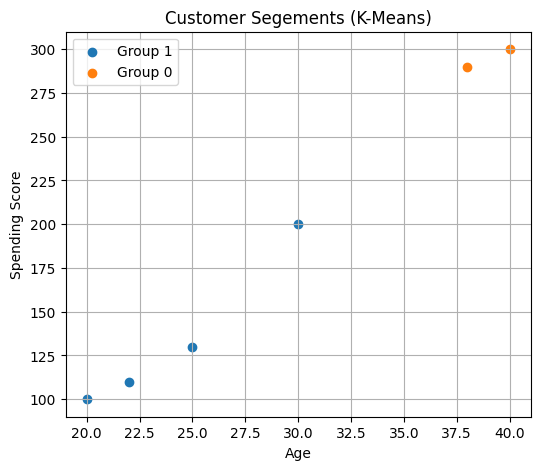

  Customer  Age  Spending  Group
0     Riya   20       100      1
1     Aman   30       200      1
2   Faizan   40       300      0
3     Neha   22       110      1
4    Imran   38       290      0
5    Sneha   25       130      1


In [8]:
X = df[['Age', 'Spending']]

model = KMeans(n_clusters=2, random_state=42, n_init=10)

df['Group'] = model.fit_predict(X)
plt.figure(figsize = (6,5))
for group in df['Group'].unique(): #[0,1]
    group_data = df[df['Group'] == group]
    plt.scatter(group_data['Age'], group_data['Spending'], label = f'Group {group}')
    
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Customer Segements (K-Means)')
plt.legend()
plt.grid(True)
plt.show()
print(df)

In [9]:
# Nest Topic - PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [11]:
df = pd.read_csv("pca.csv")

df

,Age,Income,Spending,Savings
0,25,30000,70,1000
1,30,40000,60,5000
2,35,50000,50,8000
3,40,60000,40,10000
4,45,70000,30,15000
5,50,80000,20,20000


Variance captured by each PCA Compoonent:
[99.65  0.35]


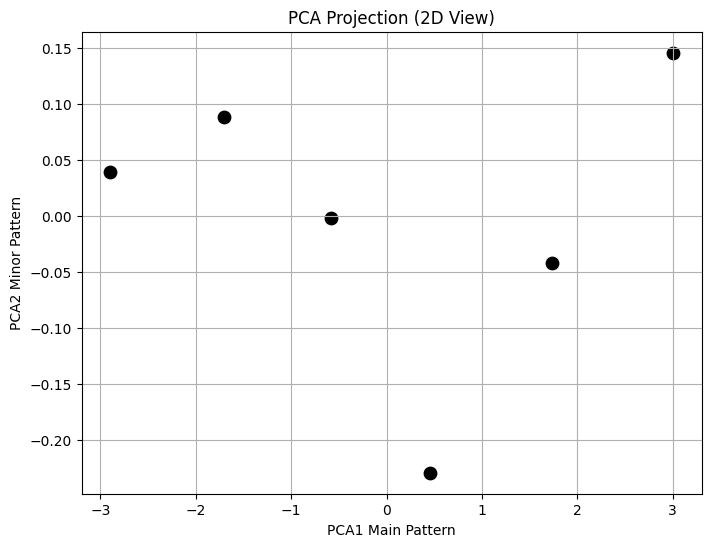

New Data with 2 feautres PCa1 Pca2
       PCA1      PCA2
0 -2.901838  0.038962
1 -1.703939  0.088054
2 -0.585677 -0.001447
3  0.452949 -0.229542
4  1.730485 -0.041856
5  3.008020  0.145829


In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])

explained_variance = pca.explained_variance_ratio_
print("Variance captured by each PCA Compoonent:")
print(np.round(explained_variance * 100,2)) #

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], color='black', s=80)
plt.title("PCA Projection (2D View)")
plt.xlabel('PCA1 Main Pattern')
plt.ylabel('PCA2 Minor Pattern')
plt.grid(True)
plt.show()

"""
resume
education 
work exp
projects
skills
pc1 = Career readiness score 100
pc2 = special skillset score 100
"""

print("New Data with 2 feautres PCa1 Pca2")
print(pca_df)

In [16]:
# Phase 2 - Student Success predictor

In [17]:
df=pd.read_csv("ssd.csv")

print("Sample Rows")
print(df.head())

print("DataSet Shape")
print(f'Rows: {df.shape[0]}, Columns:{df.shape[1]}')

print("Dataset info")
print(df.info())

print("Summary Statistics")
print(df.describe(include='all'))

print("Missing Values")
print(df.isnull().sum())

Sample Rows
   Studyhours  Attendance  Past Score Internet   Sleephours Passed
0           2          60          40       yes           5     no
1           5          80          60        no           6    yes
2           8          90          75       yes           8    yes
3           3          70          50       yes           5     no
4           7          85          70        no           7    yes
DataSet Shape
Rows: 20, Columns:6
Dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Studyhours  20 non-null     int64 
 1   Attendance  20 non-null     int64 
 2   Past Score  20 non-null     int64 
 3   Internet    20 non-null     object
 4   Sleephours  20 non-null     int64 
 5   Passed      20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB
None
Summary Statistics
        Studyhours  Attendance  Past Score 

In [18]:
from sklearn.preprocessing import LabelEncoder

In [22]:
le = LabelEncoder()
df['Internet'] = le.fit_transform(df["Internet "]) # yes =1, no =0
df['Passed'] = le.fit_transform(df["Passed"])

print("After Encoding")
print(df.head())

print('Data-types after cleaning')
print(df.dtypes)

After Encoding
   Studyhours  Attendance  Past Score Internet   Sleephours  Passed  Internet
0           2          60          40       yes           5       0         1
1           5          80          60        no           6       1         0
2           8          90          75       yes           8       1         1
3           3          70          50       yes           5       0         1
4           7          85          70        no           7       1         0
Data-types after cleaning
Studyhours     int64
Attendance     int64
Past Score     int64
Internet      object
Sleephours     int64
Passed         int64
Internet       int64
dtype: object


In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



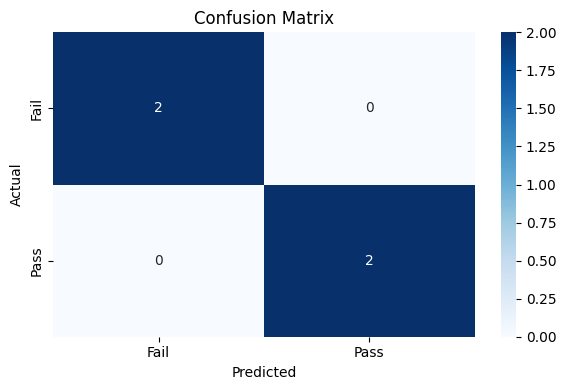

-----Predict Your Result-----


Enter study hours: 5
Enter attendance: 4
Enter past hours: 8
Enter sleep hours: 7


An error occured The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- PastScore
Feature names seen at fit time, yet now missing:
- Past Score



In [37]:
le = LabelEncoder()
df['Internet'] = le.fit_transform(df["Internet "]) # yes =1, no =0
df['Passed'] = le.fit_transform(df["Passed"])


#feature Scalling

features = ['Studyhours', 'Attendance', 'Past Score', 'Sleephours']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features]= scaler.fit_transform(df[features])

X = df_scaled[features] #feautres
y = df_scaled['Passed'] # target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels = ["Fail", "Pass"], yticklabels=["Fail", "Pass"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("-----Predict Your Result-----")
try:
    study_hours = float(input("Enter study hours:"))
    attendance = float(input("Enter attendance:"))
    past_score = float(input("Enter past hours:"))
    sleep_hours = float(input("Enter sleep hours:"))

    user_input_df= pd.DataFrame([{
        'Studyhours': study_hours,
        'Attendance': attendance,
        'PastScore': past_score,
        'Sleephours': sleep_hours
    }])

    user_input_scaled = scaler.transform(user_input_df)
    prediction = model.predict(user_input_scaled)[0]

    result = "Pass" if prediction == 1 else "Fail"
    print(f"Prediction Based on input: {result}")
except Exception as e:
    print("An error occured",e)